# QUESTION 1

## Importing the necessary libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
import matplotlib.pyplot as plt

## 1.1. Data Preparation

a) Import the Abalone dataset from the UCI Machine Learning Repository, which contains 4,177 observations and 9 variables. (5 points)

In [9]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = [
    "Sex", "Length", "Diameter", "Height", "Whole_weight",
    "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"
]

# add code here
df = pd.read_csv(url, names=column_names)
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (4177, 9)

First few rows:
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter       

Data Cleaning:

In [11]:
# one-hot encoding the 'Sex' column to convert it into a numerical column(s)

# add code here
df_encoded = pd.get_dummies(df, columns=['Sex'], prefix='Sex')

# convert the one-hot encoded columns to integers (0 and 1)

# add code here
df_encoded[['Sex_F', 'Sex_I', 'Sex_M']] = df_encoded[['Sex_F', 'Sex_I', 'Sex_M']].astype(int)

# display the first few rows of the encoded dataset

# add code here
print("Encoded dataset:")
print(df_encoded.head())
print(f"\nEncoded dataset shape: {df_encoded.shape}")

Encoded dataset:
   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  Sex_F  Sex_I  Sex_M  
0         0.150     15      0      0      1  
1         0.070      7      0      0      1  
2         0.210      9      1      0      0  
3         0.155     10      0      0      1  
4         0.055      7      0      1      0  

Encoded dataset shape: (4177, 11)


b) Split the dataset into a training set (80%) and a test set (20%) for model evaluation. Let the column 'Rings' to be the target variable. Binarize the target variable at 10 rings. (2 points)

In [16]:
# define the features (X) and target (y)

# add code here
X = df_encoded.drop('Rings', axis=1)
y = df_encoded['Rings']

# binarize the target variable for binary classification
y_binary = (y >= 10).astype(int)

print(f"Target distribution:")
print(f"Young (< 10 rings): {(y_binary == 0).sum()}")
print(f"Old (>= 10 rings): {(y_binary == 1).sum()}")


# add code here
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Target distribution:
Young (< 10 rings): 2096
Old (>= 10 rings): 2081

Training set size: 3341
Test set size: 836


## 1.2. Creating a Custom Logistic Regression Model

a) Implement a custom logistic regression model in Python. The model should be encapsulated within a class with __init__(), predict(), and train() methods. (10 points)

In [38]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    # defining a function to calculate the sigmoids
    def sigmoid(self, z):
        # Clip z to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        # Compute binary cross-entropy loss
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

    def train(self, X, y, alpha = 0.01):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.num_iterations):
            # Forward pass: compute predictions
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            
            # Backward pass: compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
           
            if (i + 1) % 100 == 0:
                print(f"Iteration {i+1}/{self.num_iterations}, Loss: {loss:.4f}")

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        # Convert probabilities to binary predictions (0 or 1)
        y_pred_class = (y_pred >= 0.5).astype(int)
        return y_pred_class

b) Train the custom logistic regression model using the training dataset. (2 points)

Iteration 100/1000, Loss: 0.4948
Iteration 200/1000, Loss: 0.4831
Iteration 300/1000, Loss: 0.4750
Iteration 400/1000, Loss: 0.4692
Iteration 500/1000, Loss: 0.4649
Iteration 600/1000, Loss: 0.4616
Iteration 700/1000, Loss: 0.4591
Iteration 800/1000, Loss: 0.4571
Iteration 900/1000, Loss: 0.4554
Iteration 1000/1000, Loss: 0.4541


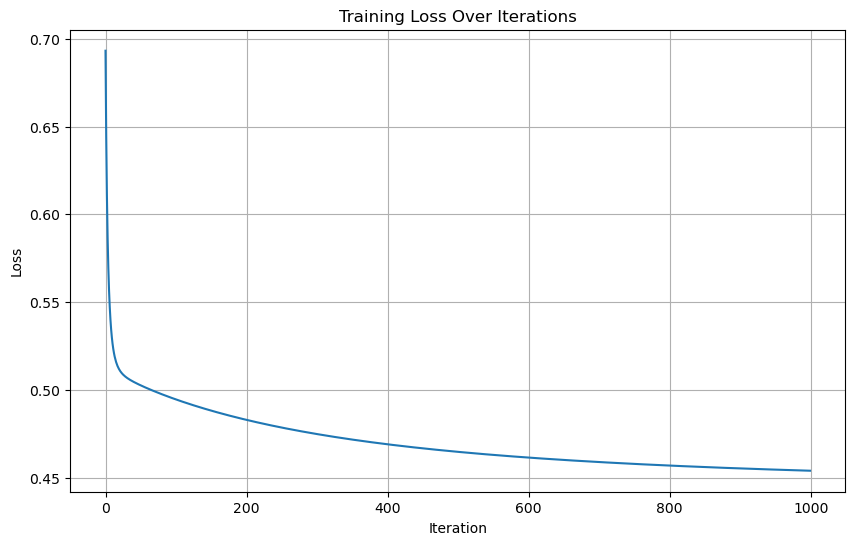

In [41]:
# Standardize features

# add code here
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train custom logistic regression model
custom_model = CustomLogisticRegression(learning_rate=0.1, num_iterations=1000)
custom_model.train(X_train_scaled, y_train.values)

# add code here
plt.figure(figsize=(10, 6))
plt.plot(custom_model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Over Iterations')
plt.grid(True)
plt.show()

## 1.3. Model Evaluation


a) Use the trained model to predict the age category for the test dataset. (2 points)


In [45]:
# Predict and evaluate
y_pred = custom_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
# add code here
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Young', 'Old']))

Accuracy: 0.7870813397129187

Classification Report:
              precision    recall  f1-score   support

       Young       0.80      0.77      0.78       421
         Old       0.77      0.81      0.79       415

    accuracy                           0.79       836
   macro avg       0.79      0.79      0.79       836
weighted avg       0.79      0.79      0.79       836



b) Calculate the confusion matrix to evaluate the model's accuracy in predicting age categories. (3 points)

When evaluating the model, you can use the built-in confusion_matrix functionality from sklearn.metrics to assess the performance of your model. This function provides a simple and efficient way to compute the confusion matrix.

In [49]:
# add code here
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[323  98]
 [ 80 335]]


c) Provide insights into the predictions, including any observations or patterns you discover. (2 points)

The logistic regression model shows an overall accuracy of approximately 78.7%, with balanced precision and recall across both age categories ('Young' and 'Old'). It correctly identifies 'Old' abalones slightly more often than 'Young' ones, as shown by the higher recall for the 'Old' class (81%) compared to 'Young' (77%). However, the model also has a slightly higher number of false positives (predicting 'Young' as 'Old') than false negatives. This indicates a minor bias towards predicting abalones as 'Old' when uncertain. Despite this, the model's performance is fairly balanced, with macro and weighted averages around 79%.







## 1.4. Visualization and Analysis

a) Generate a plot showing the loss function. (2 points)


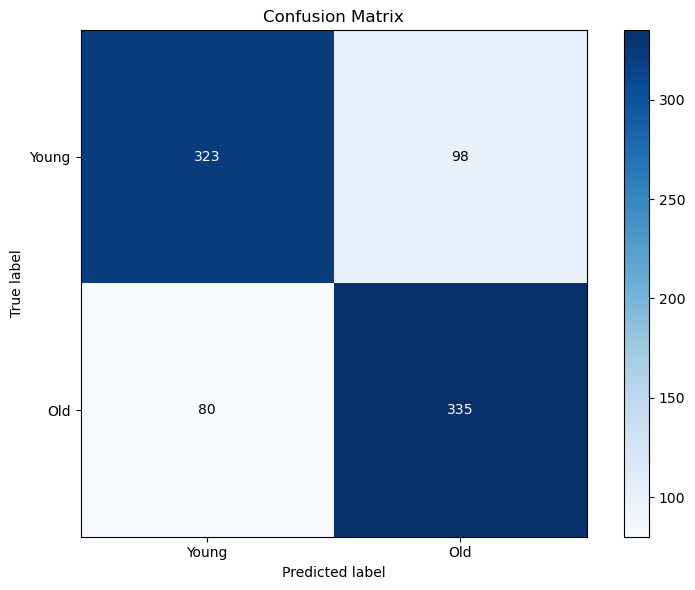


True Negatives (TN): 323
False Positives (FP): 98
False Negatives (FN): 80


In [59]:
# add code here
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Young', 'Old'])
plt.yticks(tick_marks, ['Young', 'Old'])


thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Print detailed metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

b) Explain the outcomes observed in the plots and how they relate to the model's performance. (2 points)

The custom logistic regression model demonstrates solid performance with an accuracy of approximately 78.7% (658 correct predictions out of 836 total test samples.
True Negatives (TN) = 323: The model correctly identified 323 abalones as "Young" 
True Positives (TP) = 335: The model correctly identified 335 abalones as "Old" 
False Positives (FP) = 98: The model incorrectly predicted 98 "Young" abalones as "Old" - this shows a tendency to over-predict the "Old" class
False Negatives (FN) = 80: The model incorrectly predicted 80 "Old" abalones as "Young"

The model shows better sensitivity for the "Old" class (recall = 335/(335+80) = 80.7%) compared to the "Young" class (recall = 323/(323+98) = 76.7%)


# QUESTION 2

Lasso Regularized Logistic Regression



In this question, you are required to train a **logistic regression model with Lasso (L1) regularization**. Lasso regularization adds a penalty based on the absolute values of the model's weights, encouraging sparsity by driving some weights to zero, which can help reduce overfitting by selecting only the most relevant features.

#### Model Training Steps:

1. **Define a logistic regression model** that includes an L1 penalty term. This penalty term will be proportional to the sum of the absolute values of the model's weights. The term is added directly to the loss function of logistic regression.

2. **L1 penalty (Lasso):**
   - The penalty term, commonly denoted as $$( \lambda \sum |weights| )$$, is added to the logistic regression loss function. Here, $$( \lambda )$$ is a hyperparameter that controls the strength of regularization.
   - Adding this penalty term encourages some weights to be zero, effectively selecting a subset of features.

3. **Regularization in the Loss Function**:
   - In logistic regression, the goal is to minimize the **log-loss** or **binary cross-entropy** loss. To include Lasso regularization, add the L1 penalty term to this loss function.
   - The regularized loss function is defined as:
     $$ \[
     \text{Loss}_{\text{total}} = \text{Log-Loss} + \lambda \sum |weights|
     \] $$
   - Ensure that the regularization term is applied only to the model's weights (excluding the bias term).

4. **Implementing the Regularized Logistic Loss from Scratch**:
   - Write a function to calculate the logistic loss, and add the L1 penalty term.
   - Use gradient descent or another optimization algorithm to minimize this regularized loss function.

#### Important Notes:
- When optimizing with L1 regularization, be aware that it may drive some weights to zero, effectively reducing the model's complexity by selecting a subset of features.
- Experiment with different values of $$( \lambda )$$ to find the optimal regularization strength for your data.


## Model Training


a) Train a logistic regression model with Lasso regularization. (3 points)

Iteration 100/1000, Loss: 0.5156
Iteration 200/1000, Loss: 0.5097
Iteration 300/1000, Loss: 0.5054
Iteration 400/1000, Loss: 0.5025
Iteration 500/1000, Loss: 0.5004
Iteration 600/1000, Loss: 0.4989
Iteration 700/1000, Loss: 0.4978
Iteration 800/1000, Loss: 0.4970
Iteration 900/1000, Loss: 0.4964
Iteration 1000/1000, Loss: 0.4958


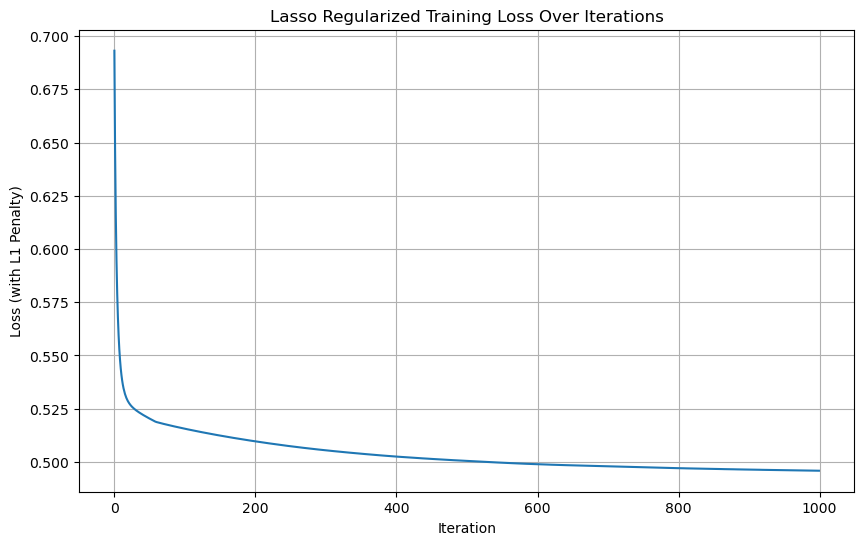

In [72]:
class CustomLassoLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, alpha=0.1):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.alpha = alpha  
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        # Compute binary cross-entropy loss with L1 regularization
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        # Binary cross-entropy loss
        bce_loss = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        
        # L1 regularization term (Lasso)
        l1_penalty = self.alpha * np.sum(np.abs(self.weights))
        
        total_loss = bce_loss + l1_penalty
        return total_loss

    def train(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.num_iterations):
            # Forward pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            
            # Backward pass: compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            
           
            dw += self.alpha * np.sign(self.weights)
            
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Print loss every 100 iterations
            if (i + 1) % 100 == 0:
                print(f"Iteration {i+1}/{self.num_iterations}, Loss: {loss:.4f}")

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        y_pred_class = (y_pred >= 0.5).astype(int)
        return y_pred_class
    
    def predict_proba(self, X):
        """Return probability estimates"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

# Train the Lasso Regularized Logistic Regression model
lasso_model = CustomLassoLogisticRegression(learning_rate=0.1, num_iterations=1000, alpha=0.01)
lasso_model.train(X_train_scaled, y_train.values)

plt.figure(figsize=(10, 6))
plt.plot(lasso_model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss (with L1 Penalty)')
plt.title('Lasso Regularized Training Loss Over Iterations')
plt.grid(True)
plt.show()


b) Display the predicted outputs for both the training and test datasets. (2 points)

In [ ]:
# Predict and evaluate on both training and test datasets
# add code here

# Display predictions
# add code here

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(lasso_model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss (with L1 Penalty)')
plt.title('Lasso Regularized Training Loss Over Iterations')
plt.grid(True)
plt.show()


c) Calculate and present the loss function associated with the Lasso regularized logistic regression model. (3 points)

In [74]:
# Predict probabilities
# add code here
# Predict and evaluate on both training and test datasets
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate accuracy
train_accuracy_lasso = accuracy_score(y_train, y_train_pred_lasso)
test_accuracy_lasso = accuracy_score(y_test, y_test_pred_lasso)

print("Lasso Regularized Logistic Regression Results:")
print("="*50)
print(f"Training Accuracy: {train_accuracy_lasso:.4f}")
print(f"Test Accuracy: {test_accuracy_lasso:.4f}")

print("\nTraining Set Classification Report:")
print(classification_report(y_train, y_train_pred_lasso, target_names=['Young', 'Old']))

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred_lasso, target_names=['Young', 'Old']))


Lasso Regularized Logistic Regression Results:
Training Accuracy: 0.7653
Test Accuracy: 0.7727

Training Set Classification Report:
              precision    recall  f1-score   support

       Young       0.77      0.76      0.76      1675
         Old       0.76      0.77      0.77      1666

    accuracy                           0.77      3341
   macro avg       0.77      0.77      0.77      3341
weighted avg       0.77      0.77      0.77      3341


Test Set Classification Report:
              precision    recall  f1-score   support

       Young       0.78      0.76      0.77       421
         Old       0.76      0.79      0.77       415

    accuracy                           0.77       836
   macro avg       0.77      0.77      0.77       836
weighted avg       0.77      0.77      0.77       836



## Evaluation Metrics

Provide evaluation metrics to assess the performance of the Lasso regularized logistic regression model on the test dataset. (5 points)

In [78]:
# add code here
# Predict probabilities
y_train_pred_proba_lasso = lasso_model.predict_proba(X_train_scaled)
y_test_pred_proba_lasso = lasso_model.predict_proba(X_test_scaled)

# Calculate log loss (without regularization penalty for comparison)
train_log_loss_lasso = log_loss(y_train, y_train_pred_proba_lasso)
test_log_loss_lasso = log_loss(y_test, y_test_pred_proba_lasso)

print("Lasso Model Loss Metrics:")
print("="*50)
print(f"Training Loss (Log Loss): {train_log_loss_lasso:.4f}")
print(f"Test Loss (Log Loss): {test_log_loss_lasso:.4f}")

# Calculate total loss with L1 penalty
l1_penalty = lasso_model.alpha * np.sum(np.abs(lasso_model.weights))
print(f"\nL1 Penalty Term: {l1_penalty:.4f}")
print(f"Total Training Loss (with L1): {train_log_loss_lasso + l1_penalty:.4f}")
print(f"Total Test Loss (with L1): {test_log_loss_lasso + l1_penalty:.4f}")


Lasso Model Loss Metrics:
Training Loss (Log Loss): 0.4682
Test Loss (Log Loss): 0.4650

L1 Penalty Term: 0.0276
Total Training Loss (with L1): 0.4958
Total Test Loss (with L1): 0.4926


# QUESTION 3

Ridge Regularized Logistic Regression





In this question, you will train a **logistic regression model with Ridge (L2) regularization**. Ridge regularization adds a penalty proportional to the square of the model's weights, which helps to prevent overfitting by shrinking the weights of less important features toward zero without making them exactly zero.

#### Model Training Steps:

1. **Define a logistic regression model** that includes an L2 penalty term. This penalty is proportional to the sum of the squared values of the model's weights.

2. **L2 penalty (Ridge):**
   - The penalty term, commonly denoted as $$( \lambda \sum weights^2 )$$, is added to the logistic regression loss function, where $$( \lambda )$$ is a hyperparameter controlling the regularization strength.
   - Unlike L1 regularization, Ridge regularization does not encourage sparsity, but it does help reduce overfitting by shrinking weights without zeroing them out.

3. **Regularization in the Loss Function**:
   - In logistic regression, the objective is to minimize the **log-loss** (or **binary cross-entropy** loss). To include Ridge regularization, add the L2 penalty term to the log-loss.
   - The regularized loss function can be expressed as:
     $$[
     \text{Loss}_{\text{total}} = \text{Log-Loss} + \lambda \sum weights^2
     ]$$
   - As with Lasso regularization, apply the penalty only to the model's weights and not the bias term.

4. **Implementing the Regularized Logistic Loss from Scratch**:
   - Write a function to calculate the logistic loss, adding the L2 penalty term for regularization.
   - Use gradient descent or another optimization method to minimize this regularized loss function.

#### Important Notes:
- Experiment with different values of $( \lambda )$ to find the optimal regularization strength for your data.
- Ridge regularization can improve model stability and prevent overfitting, especially when working with high-dimensional datasets.


## Model Training

a) Train a logistic regression model with Ridge regularization. (3 points)

Iteration 100/1000, Loss: 0.4981
Iteration 200/1000, Loss: 0.4894
Iteration 300/1000, Loss: 0.4845
Iteration 400/1000, Loss: 0.4816
Iteration 500/1000, Loss: 0.4799
Iteration 600/1000, Loss: 0.4789
Iteration 700/1000, Loss: 0.4782
Iteration 800/1000, Loss: 0.4778
Iteration 900/1000, Loss: 0.4775
Iteration 1000/1000, Loss: 0.4773


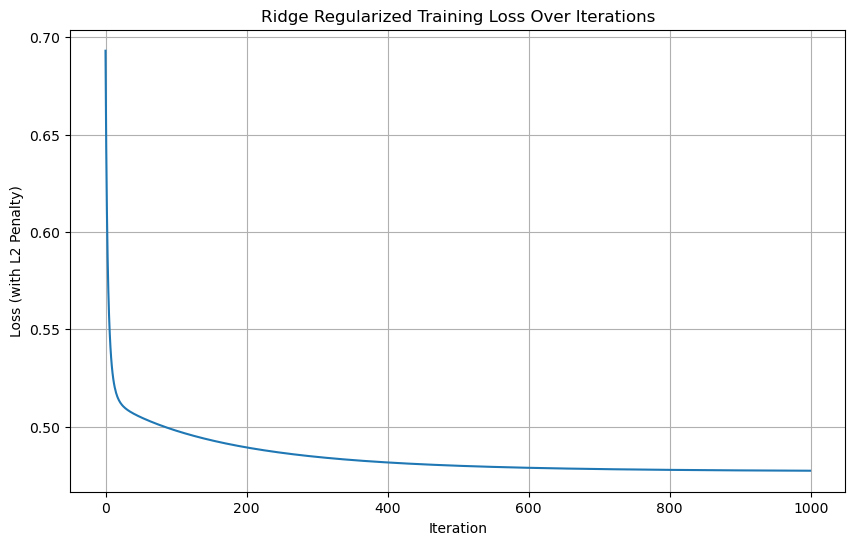

In [84]:
class CustomRidgeLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, alpha=0.1):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.alpha = alpha  
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        # Compute binary cross-entropy loss with L2 regularization
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        # Binary cross-entropy loss
        bce_loss = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        
        # L2 regularization term (Ridge)
        l2_penalty = (self.alpha / 2) * np.sum(self.weights ** 2)
        
        total_loss = bce_loss + l2_penalty
        return total_loss

    def train(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.num_iterations):
            # Forward pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            
            # Backward pass: compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            
            # Add L2 regularization gradient
            # The gradient of (1/2) * w^2 is w
            dw += self.alpha * self.weights
            
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Print loss every 100 iterations
            if (i + 1) % 100 == 0:
                print(f"Iteration {i+1}/{self.num_iterations}, Loss: {loss:.4f}")

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        y_pred_class = (y_pred >= 0.5).astype(int)
        return y_pred_class
    
    def predict_proba(self, X):
        """Return probability estimates"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

# Train the Ridge Regularized Logistic Regression model
ridge_model = CustomRidgeLogisticRegression(learning_rate=0.1, num_iterations=1000, alpha=0.01)
ridge_model.train(X_train_scaled, y_train.values)

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(ridge_model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss (with L2 Penalty)')
plt.title('Ridge Regularized Training Loss Over Iterations')
plt.grid(True)
plt.show()

b) Display the predicted outputs for both the training and test datasets. (2 points)

In [86]:
# Predict and evaluate on both training and test datasets
# add code here
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate accuracy
train_accuracy_ridge = accuracy_score(y_train, y_train_pred_ridge)
test_accuracy_ridge = accuracy_score(y_test, y_test_pred_ridge)

# Display predictions
print("Ridge Regularized Logistic Regression Results:")
print("="*50)
print(f"Training Accuracy: {train_accuracy_ridge:.4f}")
print(f"Test Accuracy: {test_accuracy_ridge:.4f}")

print("\nTraining Set Classification Report:")
print(classification_report(y_train, y_train_pred_ridge, target_names=['Young', 'Old']))

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred_ridge, target_names=['Young', 'Old']))


Ridge Regularized Logistic Regression Results:
Training Accuracy: 0.7677
Test Accuracy: 0.7799

Training Set Classification Report:
              precision    recall  f1-score   support

       Young       0.78      0.75      0.76      1675
         Old       0.76      0.79      0.77      1666

    accuracy                           0.77      3341
   macro avg       0.77      0.77      0.77      3341
weighted avg       0.77      0.77      0.77      3341


Test Set Classification Report:
              precision    recall  f1-score   support

       Young       0.80      0.75      0.77       421
         Old       0.76      0.81      0.79       415

    accuracy                           0.78       836
   macro avg       0.78      0.78      0.78       836
weighted avg       0.78      0.78      0.78       836



c) Calculate and present the loss function associated with the Ridge regularized logistic regression model. (3 points)

In [88]:
# Calculate and present the loss function
# Predict probabilities
# add code here
y_train_pred_proba_ridge = ridge_model.predict_proba(X_train_scaled)
y_test_pred_proba_ridge = ridge_model.predict_proba(X_test_scaled)

# Calculate log loss (without regularization penalty for comparison)
train_log_loss_ridge = log_loss(y_train, y_train_pred_proba_ridge)
test_log_loss_ridge = log_loss(y_test, y_test_pred_proba_ridge)

print("Ridge Model Loss Metrics:")
print("="*50)
print(f"Training Loss (Log Loss): {train_log_loss_ridge:.4f}")
print(f"Test Loss (Log Loss): {test_log_loss_ridge:.4f}")

# Calculate total loss with L2 penalty
l2_penalty = (ridge_model.alpha / 2) * np.sum(ridge_model.weights ** 2)
print(f"\nL2 Penalty Term: {l2_penalty:.4f}")
print(f"Total Training Loss (with L2): {train_log_loss_ridge + l2_penalty:.4f}")
print(f"Total Test Loss (with L2): {test_log_loss_ridge + l2_penalty:.4f}")


Ridge Model Loss Metrics:
Training Loss (Log Loss): 0.4638
Test Loss (Log Loss): 0.4595

L2 Penalty Term: 0.0136
Total Training Loss (with L2): 0.4773
Total Test Loss (with L2): 0.4730


## Evaluation Metrics

Provide evaluation metrics to assess the performance of the Ridge regularized logistic regression model on the test dataset. (5 points)

Ridge Model - Confusion Matrix:
[[316 105]
 [ 79 336]]


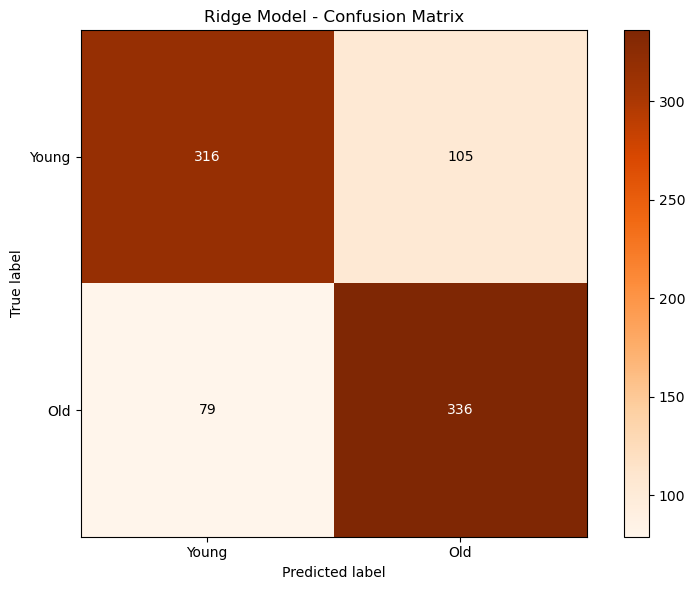


Model Coefficients (Weights):
          Feature  Coefficient  Abs_Coefficient
6    Shell_weight     1.186615         1.186615
4  Shucked_weight    -0.925210         0.925210
2          Height     0.428462         0.428462
1        Diameter     0.283718         0.283718
8           Sex_I    -0.246501         0.246501
3    Whole_weight     0.244482         0.244482
5  Viscera_weight     0.171638         0.171638
7           Sex_F     0.126937         0.126937
9           Sex_M     0.116916         0.116916
0          Length     0.050993         0.050993

Bias term: -0.0192
Sum of squared weights: 2.7105


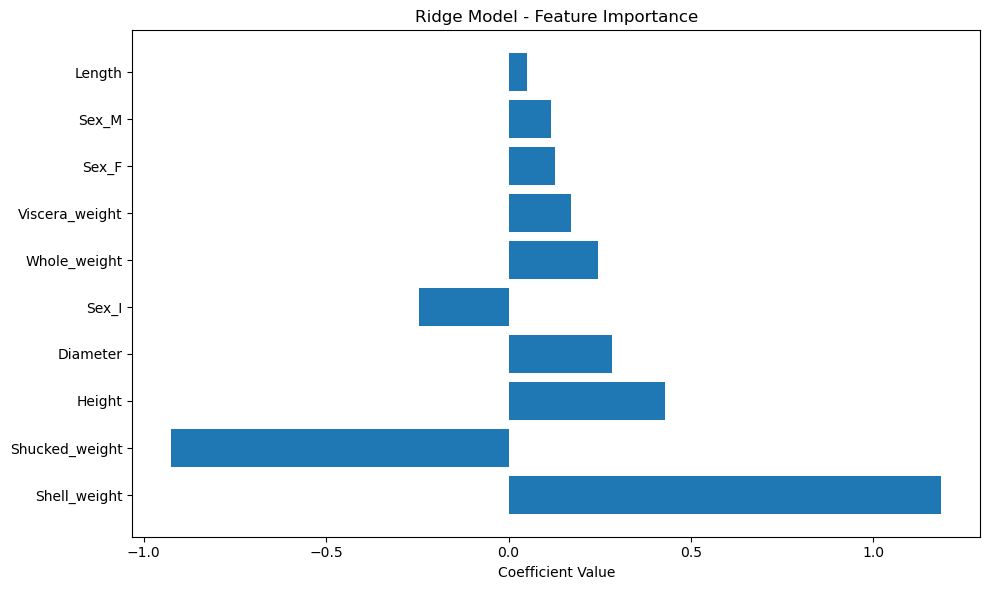

In [92]:
# add code here

# Display the coefficients
# Confusion matrix for Ridge model
cm_ridge = confusion_matrix(y_test, y_test_pred_ridge)
print("Ridge Model - Confusion Matrix:")
print(cm_ridge)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm_ridge, interpolation='nearest', cmap=plt.cm.Oranges)
plt.title('Ridge Model - Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Young', 'Old'])
plt.yticks(tick_marks, ['Young', 'Old'])

thresh = cm_ridge.max() / 2.
for i in range(cm_ridge.shape[0]):
    for j in range(cm_ridge.shape[1]):
        plt.text(j, i, format(cm_ridge[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_ridge[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Display the coefficients
print("\nModel Coefficients (Weights):")
print("="*50)
feature_names = X.columns
coefficients_ridge = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_model.weights
})
coefficients_ridge['Abs_Coefficient'] = np.abs(coefficients_ridge['Coefficient'])
coefficients_ridge = coefficients_ridge.sort_values('Abs_Coefficient', ascending=False)
print(coefficients_ridge)

print(f"\nBias term: {ridge_model.bias:.4f}")
print(f"Sum of squared weights: {np.sum(ridge_model.weights ** 2):.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(coefficients_ridge['Feature'], coefficients_ridge['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Ridge Model - Feature Importance')
plt.tight_layout()
plt.show()


# QUESTION 4

## Exponential family and the geometric distribution

(a) Consider the geometric distribution parameterized by $ \phi $:

$ p(y; \phi) = (1 - \phi)^{y-1} \phi, \quad y = 1, 2, 3, \ldots $

Show that the geometric distribution is in the exponential family, and give $ b(y) $, $ \eta $, $ T(y) $, and $ a(\eta) $. (5 points)

(b) Consider performing regression using a GLM model with a geometric response variable. What is the canonical response function for the family? You may use the fact that the mean of a geometric distribution is given by $ \frac{1}{\phi} $. (3 points)

Put your answers in a markdown cell below.

In [ ]:
a) 
p(y;η)=b(y)exp(ηTT(y)−a(η))
Given the geometric distribution:
p(y;ϕ)=(1−ϕ)y−1ϕ,y=1,2,3,…

manipulate this into exponential family form:
p(y;ϕ)=ϕ(1−ϕ)y−1
=ϕ(1−ϕ)−1(1−ϕ)y
=1−ϕϕ(1−ϕ)y

=exp(ln(1−ϕϕ)+yln(1−ϕ))
=exp(yln(1−ϕ)+ln(1−ϕϕ))
=exp(yln(1−ϕ)−(−ln(1−ϕϕ)))

Therefore, the parameters are:

b(y)=1 (the base measure is constant)
η=ln(1−ϕ) (the natural parameter)
T(y)=y (the sufficient statistic)
a(η)=−ln(1−ϕϕ)

Substituting into a(η)a(\eta)
a(η):
(η)=−ln(eη1−eη)=−ln(1−eη)+ln(eη)=η−ln(1−eη)


In [ ]:
b)
